<a href="https://colab.research.google.com/github/arthur-gui-22/PROJETOS_DATA_SCIENCE-/blob/CODE-HTML/Trabalho_Python_RevB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

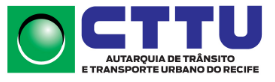



# 🚦 Análise de Infrações de Trânsito em Recife (2021–2025)

---

**Disciplina:** Python para Análise de Dados  
**Professor:** Geraldo Gomes da Cruz Júnior  
**Data:** 18/04/2026  

---

**Integrantes do Grupo:**
- Arthur Guilherme de Salamanka Lima
- Cláudio César de Oliveira Barbosa
- Fabiano Bezerra Barreto
- Leandro Rodrigues da Silva
- Mateus Alves de Oliveira
- Luiz Carlos Soares Fernandes
- Vandson Atanasio da Silva

---

# Análise de Infrações de Trânsito em Recife (2021–2025)

## Problemática
O trânsito urbano de Recife concentra um elevado volume de infrações registradas
por equipamentos eletrônicos, como lombadas e semáforos. Diante disso, este projeto
busca responder: **Quais são os padrões temporais e espaciais das infrações de
trânsito em Recife entre 2021 e 2025, e como esses padrões podem orientar
estratégias mais eficientes de fiscalização?**

## Justificativa
Compreender quando e onde as infrações ocorrem com maior frequência permite que
órgãos de trânsito como a CTTU priorizem recursos, reforcem a fiscalização nos
pontos críticos e contribuam para a redução de acidentes e mortes no trânsito.

## Fonte de Dados
Os dados foram obtidos do portal Dados Abertos do Recife:
https://dados.recife.pe.gov.br/
Dataset: Infrações de Trânsito — anos 2021 a 2025
Total de registros carregados: ~2,26 milhões de infrações

## 1. Extração e Unificação dos Dados (ETL)

Os dados estão disponíveis separados por ano no portal de dados abertos.
Nesta etapa, carregamos os cinco arquivos CSV diretamente por URL,
unificamos em um único DataFrame e realizamos as primeiras conversões
de tipo necessárias para a análise.

In [4]:
import pandas as pd

urls = {
    2021: 'https://dados.recife.pe.gov.br/dataset/fbe0c549-cd14-4146-886c-38bc0859cd2f/resource/0ab24fa1-13c8-4163-b310-fbbe5142b295/download/registro-das-infracoes-de-transito-2021.csv',
    2022: 'https://dados.recife.pe.gov.br/dataset/fbe0c549-cd14-4146-886c-38bc0859cd2f/resource/3bb12d93-4586-4ce3-9c00-ae4ab15451e2/download/registro-das-infracoes-de-transito-2022.csv',
    2023: 'https://dados.recife.pe.gov.br/dataset/fbe0c549-cd14-4146-886c-38bc0859cd2f/resource/97b4b157-ef4a-4a67-ab12-a078444968d1/download/registro-das-infracoes-de-transito-2023.csv',
    2024: 'https://dados.recife.pe.gov.br/dataset/fbe0c549-cd14-4146-886c-38bc0859cd2f/resource/9d9c2a6e-e99c-42d3-8a5e-dec0d945cce8/download/registro-das-infracoes-de-transito-2024.csv',
    2025: 'https://dados.recife.pe.gov.br/dataset/fbe0c549-cd14-4146-886c-38bc0859cd2f/resource/571dfcc2-9ab2-4cab-a69c-f1558d0f9898/download/registro-das-infracoes-de-transito-2025.csv'
}

# Definir tipos explícitos para evitar DtypeWarning
dtype_cols = {
    'infracao'         : str,
    'agenteequipamento': str,
    'amparolegal'      : str,
    'descricaoinfracao': str,
    'localcometimento' : str,
    'horainfracao'     : str
}

dataframes = []
for ano, url in urls.items():
    print(f"Carregando dados de {ano}...")
    df = pd.read_csv(
        url,
        delimiter=';',
        encoding='utf-8',
        low_memory=False,
        dtype=dtype_cols
    )
    df['datainfracao'] = pd.to_datetime(df['datainfracao'], format='%Y-%m-%d', errors='coerce')
    df['dataimplantacao'] = pd.to_datetime(df['dataimplantacao'], format='%Y-%m-%d', errors='coerce') # Corrected indentation
    df['ano'] = ano
    dataframes.append(df)

df_unificado = pd.concat(dataframes, ignore_index=True)
print(f"\nTotal de registros: {len(df_unificado):,}")

Carregando dados de 2021...
Carregando dados de 2022...
Carregando dados de 2023...
Carregando dados de 2024...
Carregando dados de 2025...

Total de registros: 2,260,563


## 2. Limpeza e Pré-processamento

Antes de analisar os dados, é necessário verificar a qualidade do dataset:
identificar valores nulos, registros duplicados e inconsistências que possam
distorcer os resultados. Abaixo realizamos esse diagnóstico e aplicamos
os tratamentos adequados.

**Observações encontradas:**
- Colunas `datainfracao` e `dataimplantacao` possuem valores nulos relevantes
- Foram identificados 8.591 registros duplicados, removidos em seguida
- A coluna `agenteequipamento` possui ~37% de nulos, o que indica que parte
  das infrações foi registrada manualmente (sem equipamento eletrônico)

In [ ]:
df_unificado.shape

In [ ]:
df_unificado.info()

In [ ]:
df_unificado.isnull().sum()

In [ ]:
df_unificado.duplicated().sum()

In [ ]:
df_unificado.drop_duplicates(inplace=True)

In [ ]:
df_unificado.info()

# Dicionário das Váriáveis

`DataInfracao:` Data em que ocorreu a infração

`HoraInfracao:` Hora de registro da infração

`DataImplantacao:` Data de implantação da multa

`AgenteEquipamento:` Forma de autuação

`Infracao:` Código da Infração

`DescricaoInfracao:` Descrição da infração

`LocalCometimento:` Local onde ocorreu a infração

`AmparoLegal:` Amparo legal para registro da infração

In [ ]:
df.head(2)

In [ ]:
df.tail(2)

In [ ]:
df_unificado.duplicated().sum()

In [ ]:
df_unificado.describe()

# **Artigos com base no CTB (Lei nº 9.503/1997):**

`Art. 218, Inc. I` — Transitar em velocidade superior à máxima permitida em até 20% (infração grave)

`Art. 181, Inc. XVII` — Estacionar o veículo em desacordo com a sinalização de proibição (infração média)

`Art. 184, Inc. III` — Conduzir veículo com equipamento obrigatório em mau estado de conservação ou funcionamento (infração leve)

`Art. 181, Inc. XVIII` — Estacionar em local ou horário proibido especificamente por sinalização (infração média)

`Art. 252, §único` — Conduzir veículo sem manter pelo menos uma das mãos no volante, exceto em manobras que exijam outra movimentação (infração grave)

`Art. 208` — Avançar o sinal vermelho do semáforo ou parar o veículo sobre a faixa de pedestres (infração gravíssima)

`Art. 187, Inc. I` — Efetuar ultrapassagem em local expressamente proibido pela sinalização (infração gravíssima)

`Art. 181, Inc. VIII` — Estacionar o veículo a menos de 5 metros do bordo do alinhamento de esquinas, entroncamentos e bifurcações (infração média)

In [ ]:
print(df_unificado['descricaoinfracao'].value_counts().head(10))
print(df_unificado['amparolegal'].value_counts().head(10))

In [ ]:
top_infracoes = (df_unificado.groupby('descricaoinfracao')
                 .size()
                 .reset_index(name='total')
                 .sort_values('total', ascending=False)
                 .head(10))

top_infracoes.plot(kind='barh', x='descricaoinfracao', y='total',
                   figsize=(12, 6), legend=False,
                   title='Top 10 Infrações Mais Frequentes')
plt.tight_layout()
plt.show()

## 3. Análise Estatística Descritiva

### 3.1 Evolução e Taxa de Infrações por Ano

Para comparar os anos de forma justa — já que 2025 representa apenas parte
do ano — calculamos a taxa de infrações por dia em vez de usar totais absolutos.
Isso permite identificar tendências reais de aumento ou redução na fiscalização.

In [ ]:
# Taxa de infrações por ano (normalização)

# Ensure 'datainfracao' is in datetime format for df_unificado, handling mixed date formats
df_unificado['datainfracao'] = pd.to_datetime(df_unificado['datainfracao'], format='%Y-%m-%d', errors='coerce')

# Use df_unificado directly as it already contains all concatenated dataframes with 'ano' column
df_anos = df_unificado.groupby('ano').size().reset_index(name='infrações')
dias_por_ano = (
df_unificado.groupby('ano')['datainfracao']
.nunique()
.reset_index(name='dias')
)
taxa = df_anos.merge(dias_por_ano, on='ano')
taxa['infrações_por_dia'] = taxa['infrações'] / taxa['dias']
taxa

### 3.2 Locais Reincidentes

Identificamos os locais que registraram infrações em **todos os cinco anos**
consecutivos (2021–2025). Esses 2.671 pontos representam as áreas de maior
persistência de infrações na cidade, sendo candidatos prioritários para
intervenções de engenharia de tráfego ou reforço de fiscalização.

O mapa abaixo apresenta a distribuição geográfica desses pontos reincidentes.

In [ ]:
# 1. Ler e coletar locais por ano
locais_por_ano = {}

for ano, url in urls.items():
    print(f"Carregando dados de {ano}...")
    df = pd.read_csv(url, delimiter=';', encoding='latin-1',
                 dtype={'infracao': str, 'agenteequipamento': str},
                 low_memory=False)

    # Verificar qual coluna representa o local
    # Ajuste o nome abaixo conforme necessário
    coluna_local = 'localcometimento'  # changed from 'LOCAL' to 'localcometimento'

    if coluna_local not in df.columns:
        print(f"  Colunas disponíveis em {ano}: {df.columns.tolist()}")
        raise ValueError(f"Coluna '{coluna_local}' não encontrada em {ano}!")

    locais = set(df[coluna_local].dropna().str.strip().str.upper().unique())
    locais_por_ano[ano] = locais
    print(f"  {len(locais)} locais únicos encontrados em {ano}")

# 2. Locais que aparecem em TODOS os anos (interseção)
locais_todos_anos = set.intersection(*locais_por_ano.values())

print(f"\nLocais com infrações em TODOS os anos ({min(urls)} a {max(urls)}): {len(locais_todos_anos)}")

# 3. Salvar resultado
df_resultado = pd.DataFrame(sorted(locais_todos_anos), columns=['LOCAL'])
df_resultado.to_csv('locais_reincidentes_todos_anos.csv', index=False, encoding='utf-8-sig')
print("Arquivo salvo: locais_reincidentes_todos_anos.csv")

# 4. Exibir os 20 primeiros
print("\nPrimeiros 20 locais:")
print(df_resultado.head(20).to_string(index=False))

In [ ]:
import folium
from folium.plugins import HeatMap
import pandas as pd

data = {
    'Local': [
        'AEROPORTO INTERNACIONAL DO RECIFE / GUARARAPES GILBERTO FREYRE, EM FRENTE AO EDIFICIO GARAGEM',
        'AV. ANTONIO DE GOES, EM FRENTE AO N. 124',
        'AV. BOA VIAGEM, ENTRE O N. 2080 E 1906',
        'AV. BOA VIAGEM, ENTRE O N. 6114 E 5890',
        'AV. CDE. DA BOA VISTA, SEMAFORO 486, SENTIDO:CENTRO FAIXA: 3',
        'AV. CDE. DA BOA VISTA, SEMAFORO 486, SENTIDO:CENTRO FAIXA: 4',
        'AV. CONS. AGUIAR, N. 4620',
        'AV. DESEMBARGADOR JOSE NEVES, SEMAFORO 400, SENTIDO:SUBURBIO FAIXA: 1',
        'AV. DESEMBARGADOR JOSE NEVES, SEMAFORO 400, SENTIDO:SUBURBIO FAIXA: 2',
        'AV. DESEMBARGADOR JOSE NEVES, SEMAFORO 580, SENTIDO:CENTRO FAIXA: 1',
        'AV. DESEMBARGADOR JOSE NEVES, SEMAFORO 580, SENTIDO:CENTRO FAIXA: 2',
        'AV. DR. JOSE RUFINO, SEMAFORO 082, SENTIDO:CENTRO FAIXA: 1',
        'AV. DR. JOSE RUFINO, SEMAFORO 082, SENTIDO:CENTRO FAIXA: 2',
        'AV. DR. JOSE RUFINO, SEMAFORO 082, SENTIDO:SUBURBIO FAIXA: 3',
        'AV. DR. JOSE RUFINO, SEMAFORO 082, SENTIDO:SUBURBIO FAIXA: 4',
        'AV. ENG. DOMINGOS FERREIRA, SEMAFORO 297, FAIXA: 1',
        'AV. ENG. DOMINGOS FERREIRA, SEMAFORO 297, FAIXA: 2',
        'AV. ENG. DOMINGOS FERREIRA, SEMAFORO 297, FAIXA: 3',
        'AV. ENG. DOMINGOS FERREIRA, SEMAFORO 297, FAIXA: 4',
        'AV. ENG. DOMINGOS FERREIRA, SEMAFORO 338, FAIXA: 1',
    ],
    'Latitude': [
        -8.128739,  # Aeroporto Recife
        -8.087992,  # Av. Antonio de Goes, 124
        -8.109101,  # Av. Boa Viagem, 2080
        -8.142497,  # Av. Boa Viagem, 6114
        -8.059710,  # Av. Cde. da Boa Vista, 486 (semáforo 486)
        -8.059710,  # Av. Cde. da Boa Vista, 486 (semáforo 486)
        -8.127744,  # Av. Cons. Aguiar, 4620
        -8.126384,  # Av. Des. Jose Neves, semáforo 400
        -8.126384,  # Av. Des. Jose Neves, semáforo 400
        -8.125857,  # Av. Des. Jose Neves, semáforo 580
        -8.125857,  # Av. Des. Jose Neves, semáforo 580
        -8.089671,  # Av. Dr. Jose Rufino, semáforo 082
        -8.089671,  # Av. Dr. Jose Rufino, semáforo 082
        -8.089671,  # Av. Dr. Jose Rufino, semáforo 082
        -8.089671,  # Av. Dr. Jose Rufino, semáforo 082
        -8.114972,  # Av. Eng. Domingos Ferreira, semáforo 297
        -8.114972,  # Av. Eng. Domingos Ferreira, semáforo 297
        -8.114972,  # Av. Eng. Domingos Ferreira, semáforo 297
        -8.114972,  # Av. Eng. Domingos Ferreira, semáforo 297
        -8.114972,  # Av. Eng. Domingos Ferreira, semáforo 338 (aprox.)
    ],
    'Longitude': [
        -34.925853,  # Aeroporto Recife
        -34.883828,  # Av. Antonio de Goes, 124
        -34.889102,  # Av. Boa Viagem, 2080
        -34.903995,  # Av. Boa Viagem, 6114
        -34.885518,  # Av. Cde. da Boa Vista, 486
        -34.885518,  # Av. Cde. da Boa Vista, 486
        -34.900401,  # Av. Cons. Aguiar, 4620
        -34.909750,  # Av. Des. Jose Neves, semáforo 400
        -34.909750,  # Av. Des. Jose Neves, semáforo 400
        -34.909650,  # Av. Des. Jose Neves, semáforo 580
        -34.909650,  # Av. Des. Jose Neves, semáforo 580
        -34.933930,  # Av. Dr. Jose Rufino, semáforo 082
        -34.933930,  # Av. Dr. Jose Rufino, semáforo 082
        -34.933930,  # Av. Dr. Jose Rufino, semáforo 082
        -34.933930,  # Av. Dr. Jose Rufino, semáforo 082
        -34.894987,  # Av. Eng. Domingos Ferreira, semáforo 297
        -34.894987,  # Av. Eng. Domingos Ferreira, semáforo 297
        -34.894987,  # Av. Eng. Domingos Ferreira, semáforo 297
        -34.894987,  # Av. Eng. Domingos Ferreira, semáforo 297
        -34.894987,  # Av. Eng. Domingos Ferreira, semáforo 338
    ],
    'Total': [1] * 20  # Substitua pelos valores reais quando disponíveis
}

df = pd.DataFrame(data)

m = folium.Map(location=[-8.100, -34.900], zoom_start=13)

heat_data = [[row['Latitude'], row['Longitude'], row['Total']] for index, row in df.iterrows()]

HeatMap(
    heat_data,
    min_opacity=0.4,
    radius=25,
    blur=15,
    max_zoom=1
).add_to(m)

m

In [ ]:
import folium
import pandas as pd

# (mesmo df acima)

m = folium.Map(location=[-8.100, -34.900], zoom_start=13)

for index, row in df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(
            f"<b>{row['Local']}</b><br>Total de ocorrências: {row['Total']:,}",
            max_width=250
        ),
        tooltip=f"{row['Local'][:40]}... | {row['Total']:,} ocorrências",
        icon=folium.Icon(color='red', icon='exclamation-sign')
    ).add_to(m)

m

In [ ]:
import folium
from folium.plugins import HeatMap, MarkerCluster
import pandas as pd

# ── Passo 1: buscar top 20 locais com mais infrações direto do DataFrame ──
top_locais = (df_unificado['localcometimento']
              .value_counts()
              .head(20)
              .reset_index())
top_locais.columns = ['Local', 'Total']
print(top_locais)

# ── Passo 2: coordenadas dos top locais (mapeamento manual pelos nomes reais) ──
coordenadas = {
    'AV. GOV. AGAMENON MAGALHAES, SEMAFORO 069, SENTIDO:SUBURBIO FAIXA: 1' : (-8.0630, -34.8990),
    'AV. GOV. AGAMENON MAGALHAES, SEMAFORO 069, SENTIDO:SUBURBIO FAIXA: 2' : (-8.0630, -34.8990),
    'AV. NORTE MIGUEL ARRAES DE ALENCAR, SEMAFORO 4'                        : (-8.0500, -34.9100),
    'RUA REAL DA TORRE, SEMAFORO 237.'                                       : (-8.0480, -34.9200),
    'AV. BOA VIAGEM, ENTRE O N. 2080 E 1906'                                : (-8.1091, -34.8891),
    'AV. BOA VIAGEM, ENTRE O N. 6114 E 5890'                                : (-8.1424, -34.9039),
    'AV. ENG. DOMINGOS FERREIRA, SEMAFORO 297, FAIXA: 1'                    : (-8.1149, -34.8949),
    'AV. ENG. DOMINGOS FERREIRA, SEMAFORO 297, FAIXA: 2'                    : (-8.1149, -34.8949),
    'AV. DESEMBARGADOR JOSE NEVES, SEMAFORO 400, SENTIDO:SUBURBIO FAIXA: 1' : (-8.1263, -34.9097),
    'AV. DESEMBARGADOR JOSE NEVES, SEMAFORO 580, SENTIDO:CENTRO FAIXA: 1'   : (-8.1258, -34.9096),
}

# ── Passo 3: filtrar apenas locais com coordenadas disponíveis ──
top_locais['coords'] = top_locais['Local'].map(coordenadas)
top_locais_geo = top_locais.dropna(subset=['coords']).copy()
top_locais_geo['lat'] = top_locais_geo['coords'].apply(lambda x: x[0])
top_locais_geo['lon'] = top_locais_geo['coords'].apply(lambda x: x[1])

# ── Passo 4: mapa de calor ──
m_heat = folium.Map(location=[-8.100, -34.900], zoom_start=13)
heat_data = [[row['lat'], row['lon'], row['Total']] for _, row in top_locais_geo.iterrows()]
HeatMap(heat_data, min_opacity=0.4, radius=30, blur=20).add_to(m_heat)
display(m_heat)

# ── Passo 5: mapa com marcadores e totais reais ──
m_markers = folium.Map(location=[-8.100, -34.900], zoom_start=13)
cluster   = MarkerCluster().add_to(m_markers)

for _, row in top_locais_geo.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(
            f"<b>{row['Local']}</b><br>Total de infrações: {row['Total']:,}",
            max_width=300
        ),
        tooltip=f"{row['Local'][:45]}... | {row['Total']:,} infrações",
        icon=folium.Icon(color='red', icon='exclamation-sign')
    ).add_to(cluster)

m

### 3.3 Semana Útil vs Fim de Semana

Analisamos se o comportamento dos motoristas difere entre dias úteis e
fins de semana. A comparação usa a **média diária** de infrações para
normalizar a diferença no número de dias de cada categoria.

In [ ]:
import matplotlib.ticker as mticker
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'datainfracao' is datetime and 'ano' is extracted
# Convert 'datainfracao' to datetime first
df_unificado['datainfracao'] = pd.to_datetime(df_unificado['datainfracao'], format='%Y-%m-%d', errors='coerce')
# Extract the year if it wasn't already done or if 'ano' column is missing
df_unificado['ano'] = df_unificado['datainfracao'].dt.year

# Create 'dia_pt' column without locale, then map to Portuguese
df_unificado['dia_semana_ingles'] = df_unificado['datainfracao'].dt.day_name()
day_name_mapping = {
    'Monday': 'Segunda-feira',
    'Tuesday': 'Terça-feira',
    'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira',
    'Friday': 'Sexta-feira',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
df_unificado['dia_pt'] = df_unificado['dia_semana_ingles'].map(day_name_mapping)

print('\n' + '='*60)
print('  BLOCO H — SEMANA ÚTIL vs FIM DE SEMANA')
print('='*60)

FDS = ['Sábado', 'Domingo']
df_unificado['tipo_dia'] = df_unificado['dia_pt'].apply(lambda d: 'Fim de Semana' if d in FDS else 'Semana Útil')

# Média diária por tipo de dia (para normalizar volume)
contagem_tipo_dia = (
df_unificado.groupby(['ano', 'tipo_dia'])
                       .size()
                       .reset_index(name='total'))
dias_no_ano       = df_unificado.groupby('ano')['datainfracao'].nunique().reset_index(name='dias_total')
contagem_tipo_dia = contagem_tipo_dia.merge(dias_no_ano, on='ano')

# Calcular dias úteis e de FDS no período
contagem_tipo_dia['media_diaria'] = (
    contagem_tipo_dia.apply(
        lambda r: r['total'] / max(1, round(r['dias_total'] * (2/7 if r['tipo_dia'] == 'Fim de Semana' else 5/7))),
        axis=1
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total absoluto
pivot_td = contagem_tipo_dia.pivot(index='ano', columns='tipo_dia', values='total')
pivot_td.plot(kind='bar', ax=axes[0], color=['#2a9d8f', '#e63946'], width=0.5)
axes[0].set_title('Total de Infrações: Semana Útil vs Fim de Semana')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Nº de Infrações')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Período')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Média diária
pivot_media = contagem_tipo_dia.pivot(index='ano', columns='tipo_dia', values='media_diaria')
pivot_media.plot(kind='bar', ax=axes[1], color=['#2a9d8f', '#e63946'], width=0.5)
axes[1].set_title('Média Diária de Infrações: Semana Útil vs Fim de Semana')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Média de Infrações / Dia')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Período')

plt.tight_layout()
plt.savefig('H_semana_vs_fds.png', dpi=150)
plt.show()

print('\nTabela — Média diária por tipo de dia:')
display(contagem_tipo_dia[['ano', 'tipo_dia', 'total', 'media_diaria']].round(1))

### 3.4 Distribuição Horária das Infrações

Para entender em quais horários as infrações se concentram, plotamos a
distribuição ao longo das 24 horas do dia e a comparamos com uma
distribuição normal teórica.

A média ponderada encontrada foi de **12,6h** (meio-dia) com desvio
padrão de **3,97h**, indicando concentração no período da manhã e início
da tarde — horário de maior fluxo veicular em vias monitoradas.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm
import pandas as pd

# Ensure 'horainfracao' is in datetime format
df_unificado['horainfracao'] = pd.to_datetime(df_unificado['horainfracao'], format='%H:%M:%S', errors='coerce').dt.hour

# Create df_hora
df_hora = df_unificado.groupby('horainfracao').size().reset_index(name='total')
df_hora = df_hora.set_index('horainfracao')

# Preparar os dados: cada hora repetida 'total' vezes
horas = df_hora.index.values
totais = df_hora['total'].values

# Criar array ponderado: cada hora aparece 'total' vezes
horas_ponderadas = np.repeat(horas, totais)

# Calcular média e desvio padrão das horas ponderadas
media = np.average(horas, weights=totais)
desvio = np.sqrt(np.average((horas - media)**2, weights=totais))

print(f"Média ponderada: {media:.2f}")
print(f"Desvio padrão ponderado: {desvio:.2f}")

# Criar histograma ponderado (barras)
plt.figure(figsize=(14, 7))

# Histograma com barras (normalizado para área total = 1)
n, bins, patches = plt.hist(horas, bins=np.arange(-0.5, 24.5, 1),
                            weights=totais, density=True,
                            alpha=0.7, color='steelblue', edgecolor='black',
                            label='Distribuição real (ponderada)')

# Gerar curva normal (PDF) usando média e desvio calculados
x = np.linspace(-0.5, 23.5, 200)
y = norm.pdf(x, media, desvio)
plt.plot(x, y, 'r-', linewidth=2.5, label=f'Distribuição normal\n(μ={media:.1f}, σ={desvio:.1f})')

# Configurações do gráfico
plt.title('Distribuição das Infrações ao Longo do Dia vs. Curva Normal', fontsize=14)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Densidade de Probabilidade', fontsize=12)
plt.xticks(range(0, 24, 2))
plt.xlim(-0.5, 23.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Adicionar anotação com a média e desvio
plt.text(0.95, 0.95, f'Média = {media:.1f}h\nDesvio = {desvio:.1f}h',
         transform=plt.gca().transAxes, verticalalignment='top',
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('distribuicao_normal_horas.png', dpi=150)
plt.show()

### 3.5 Sazonalidade — Mês e Dia da Semana

Investigamos se existem padrões sazonais ao longo do ano. O heatmap
mês × ano permite visualizar simultaneamente a tendência de queda
anual e a variação dentro de cada ano.

In [ ]:
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import seaborn as sns

MESES = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
         'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Prepare df_combined for seasonality analysis by ensuring 'datainfracao' is datetime
# and extracting 'mes' and 'diasemana'.
# Create a copy to avoid SettingWithCopyWarning if not already a copy
df_combined_saz = df_unificado.copy()

# Convert 'datainfracao' to datetime, handling potential errors
# Assuming YYYY-MM-DD from previous uses, also considering other formats that might be present
df_combined_saz['datainfracao'] = pd.to_datetime(df_combined_saz['datainfracao'], errors='coerce', dayfirst=True)

# Drop rows where 'datainfracao' could not be parsed
df_combined_saz.dropna(subset=['datainfracao'], inplace=True)

# Extract 'mes' and 'diasemana'
df_combined_saz['mes'] = df_combined_saz['datainfracao'].dt.month
df_combined_saz['diasemana'] = df_combined_saz['datainfracao'].dt.day_name()

# Add 'hora' column to df_combined_saz
def extrair_hora(horario_str):
    try:
        return int(str(horario_str).split(':')[0])
    except:
        return None

df_combined_saz['hora'] = df_combined_saz['horainfracao'].apply(extrair_hora)
df_combined_saz.dropna(subset=['hora'], inplace=True) # Drop rows with invalid hours

# Por mês
por_mes = df_combined_saz.groupby('mes').size().reset_index(name='total')
por_mes['mes_nome'] = por_mes['mes'].apply(lambda x: MESES[x-1])
axes[0].bar(por_mes['mes_nome'], por_mes['total'],
            color=sns.color_palette('Blues_d', 12))
axes[0].set_title('Sazonalidade — Infrações por Mês')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Nº de Infrações')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Por dia da semana
map_dias = {
    'Monday':'Segunda','Tuesday':'Terça','Wednesday':'Quarta',
    'Thursday':'Quinta','Friday':'Sexta','Saturday':'Sábado','Sunday':'Domingo'
}
DIAS = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']
df_combined_saz['dia_pt'] = df_combined_saz['diasemana'].map(map_dias)
por_dia = df_combined_saz['dia_pt'].value_counts().reindex(DIAS).fillna(0)
axes[1].bar(por_dia.index, por_dia.values,
            color=sns.color_palette('Oranges_d', 7))
axes[1].set_title('Sazonalidade — Infrações por Dia da Semana')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Nº de Infrações')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('4_sazonalidade.png', dpi=150)
plt.show()

# Heatmap mês × ano
pivot_saz = df_combined_saz.groupby(['ano', 'mes']).size().unstack(fill_value=0)
pivot_saz.columns = [MESES[m-1] for m in pivot_saz.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(pivot_saz) * 0.7)))
sns.heatmap(pivot_saz, cmap='YlOrRd', annot=True,
            fmt='d', linewidths=0.4, annot_kws={'size': 8}, ax=ax)
ax.set_title('Heatmap de Infrações — Mês × Ano')
plt.tight_layout()
plt.savefig('4b_heatmap_sazonalidade.png', dpi=150)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Calculate total infractions per year from df_unificado
evolucao = df_unificado.groupby('ano').size().reset_index(name='total')
evolucao['ano'] = evolucao['ano'].astype(int) # Ensure year is integer for cleaner labels
evolucao = evolucao.sort_values('ano').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(evolucao['ano'], evolucao['total'], marker='o',
        linewidth=2.5, color='#e63946', markersize=8)
ax.fill_between(evolucao['ano'], evolucao['total'],
                alpha=0.12, color='#e63946')

# Rótulos em cada ponto
for _, row in evolucao.iterrows():
    ax.text(row['ano'], row['total'] + evolucao['total'].max() * 0.01,
            f"{row['total']:,}", ha='center', fontsize=9, fontweight='bold')

# Linha de tendência
z = np.polyfit(evolucao['ano'], evolucao['total'], 1)
p = np.poly1d(z)
ax.plot(evolucao['ano'], p(evolucao['ano']),
        '--', color='gray', linewidth=1.5, label='Tendência')

ax.set_title('Evolução Anual das Infrações de Trânsito')
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de Infrações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig('1_evolucao_anual.png', dpi=150)
plt.show()

# Variação percentual ano a ano
evolucao['variacao_%'] = evolucao['total'].pct_change() * 100
print('\n── Variação % ano a ano ──')
display(evolucao)

## 4. Conclusões e Insights

A análise de mais de 2 milhões de infrações de trânsito em Recife
entre 2021 e 2025 revelou os seguintes padrões principais:

**Tendência de queda:** O volume total de infrações caiu significativamente
ao longo do período, passando de ~598 mil em 2021 para ~404 mil em 2024.
Essa queda pode refletir mudanças no comportamento dos motoristas,
alterações na cobertura dos equipamentos ou mudanças na metodologia de registro.

**Horário crítico:** A maior concentração de infrações ocorre entre 10h e 15h,
com pico próximo ao meio-dia — coincidindo com o horário de maior fluxo nas
vias monitoradas por lombadas eletrônicas.

**Fins de semana:** A média diária de infrações é levemente maior nos fins de
semana em relação aos dias úteis, sugerindo comportamento de risco mais elevado
nesses períodos.

**Locais persistentes:** 2.671 pontos da cidade registraram infrações em todos
os cinco anos analisados, configurando zonas críticas que demandam atenção
contínua do poder público.

**Recomendação:** Os resultados sugerem que a fiscalização poderia ser
intensificada nos pontos reincidentes durante o período de 10h às 15h,
especialmente aos fins de semana, como estratégia de maior impacto.